In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mu0 = 4 * np.pi * 1e-7  # vacuum permeability [T m/A]

B_RESULTS_CSV_PATH = "B_results.csv"
METADATA_CSV_PATH = "B_results_metadata.csv"

B_COMPONENTS = ["Bx", "By", "Bz"]
CMAP_B = "seismic"
CMAP_K = "viridis"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

In [ ]:

B_df = pd.read_csv(B_RESULTS_CSV_PATH)
B_df = B_df.sort_values(["row", "col"]).reset_index(drop=True)

grid_size = int(np.sqrt(len(B_df)))
if grid_size * grid_size != len(B_df):
    raise ValueError("B_results.csv does not contain a square grid.")

x_grid_um = B_df["x_um"].to_numpy().reshape(grid_size, grid_size)
y_grid_um = B_df["y_um"].to_numpy().reshape(grid_size, grid_size)

x_values_um = x_grid_um[0, :]
y_values_um = y_grid_um[:, 0]

dx_um = float(np.mean(np.diff(x_values_um)))
dy_um = float(np.mean(np.diff(y_values_um)))

dx_m = dx_um * 1e-6
dy_m = dy_um * 1e-6

extent_um = [
    float(np.nanmin(x_grid_um)),
    float(np.nanmax(x_grid_um)),
    float(np.nanmin(y_grid_um)),
    float(np.nanmax(y_grid_um)),
]

B_pos_nT = np.stack([
    B_df["Bx_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_pos_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_neg_nT = np.stack([
    B_df["Bx_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_neg_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_odd_nT = np.stack([
    B_df["Bx_odd_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_odd_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_odd_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_even_nT = np.stack([
    B_df["Bx_even_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_even_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_even_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

#metadata

metadata_df = pd.read_csv(METADATA_CSV_PATH)

def get_metadata_value(key, default=None, cast=float):
    matches = metadata_df.loc[metadata_df["key"] == key, "value"]

    if len(matches) == 0:
        print(f"Metadata key '{key}' not found. Using default: {default}")
        return default

    value = matches.iloc[0]

    if cast is None:
        return value

    try:
        return cast(value)
    except Exception:
        print(f"Could not cast metadata key '{key}' = {value}. Using default: {default}")
        return default

I_POS_mA = get_metadata_value("current_pos_mA", default=2.0, cast=float)
I_NEG_mA = get_metadata_value("current_neg_mA", default=-2.0, cast=float)
PULSE_AMPLITUDE_mV = get_metadata_value("pulse_amplitude_mV", default=10.0, cast=float)


In [ ]:
# ============================================================
# Geometry used only for current-integration diagnostics

WIRE_THETA_DEG = -4.82         # approximate wire direction from geometry/simulation
EFFECTIVE_HEIGHT_UM = 18.99    # first-choice effective standoff for reconstruction

theta = np.deg2rad(WIRE_THETA_DEG)

# Unit vector parallel to the nominal wire/current direction
u_parallel = np.array([np.sin(theta), np.cos(theta)])

# Unit vector perpendicular to the wire direction
u_perp = np.array([np.cos(theta), -np.sin(theta)])

print("Current-density reconstruction geometry")
print("--------------------------------------")
print(f"WIRE_THETA_DEG = {WIRE_THETA_DEG:.2f} deg")
print(f"u_parallel = ({u_parallel[0]:+.4f}, {u_parallel[1]:+.4f})")
print(f"u_perp     = ({u_perp[0]:+.4f}, {u_perp[1]:+.4f})")
print(f"First-choice effective standoff = {EFFECTIVE_HEIGHT_UM:.1f} µm")

Current-density reconstruction geometry
--------------------------------------
WIRE_THETA_DEG = -4.82 deg
u_parallel = (-0.0840, +0.9965)
u_perp     = (+0.9965, +0.0840)
First-choice effective standoff = 19.0 µm


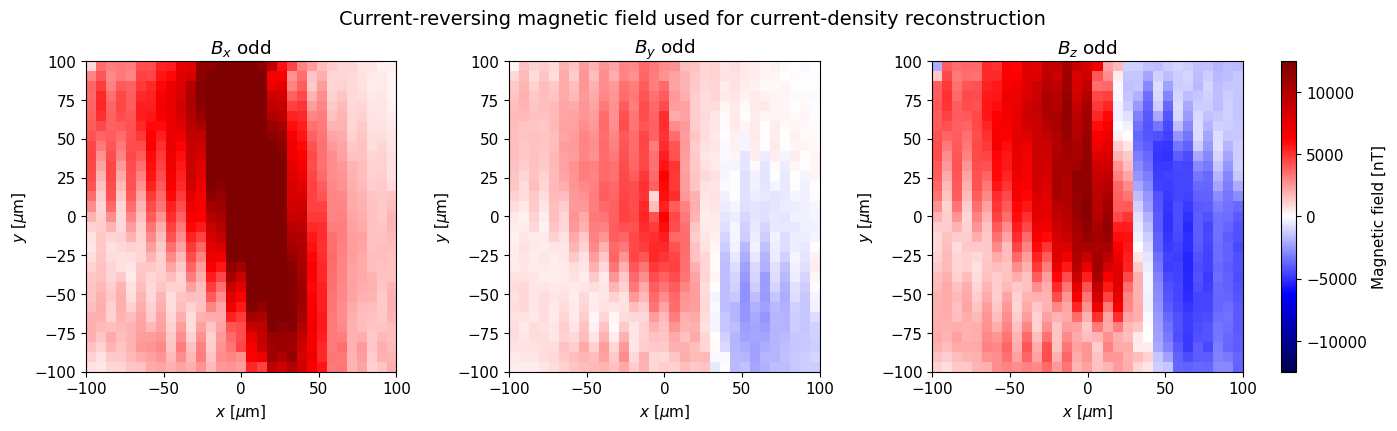

In [ ]:
# ============================================================
# Plot current-reversing odd magnetic field
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)

global_lim = np.nanpercentile(np.abs(B_odd_nT), 95)
if global_lim == 0 or not np.isfinite(global_lim):
    global_lim = 1.0

for i, comp in enumerate(B_COMPONENTS):
    data = B_odd_nT[i]

    im = axes[i].imshow(
        data,
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP_B,
        vmin=-global_lim,
        vmax=+global_lim,
    )
    
    axes[i].set_title(rf"${comp[0]}_{comp[1]}$ odd")
    axes[i].set_xlabel(r"$x$ [$\mu$m]")
    axes[i].set_ylabel(r"$y$ [$\mu$m]")

cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label("Magnetic field [nT]")

fig.suptitle(
    "Current-reversing magnetic field used for current-density reconstruction",
    fontsize=14,
)

plt.show()

# functions for reconstructin current, only Bz and from all components


In [ ]:
# Bz-only Fourier current-density reconstruction


def reconstruct_current_from_Bz_only(
    Bz_nT,
    dx_m,
    dy_m,
    stand_off_um,
    k_filter_fraction=0.25,
    filter_power=4,
):
    """
    Reconstruct effective 2D sheet current K(x,y) from Bz only.

    Assumptions
    -----------
    - Current is represented as an effective 2D sheet current:
          K(x,y) = (Kx, Ky)
    - The sheet current is divergence-free:
          div K = 0
    - Therefore K can be written using a stream function g:
          Kx =  dg/dy
          Ky = -dg/dx
    - For a sheet current at effective standoff h:
          Bz(k,h) = (mu0/2) * k * exp(-k h) * g(k)

    Parameters
    ----------
    Bz_nT:
        Out-of-plane magnetic field in nT.
    dx_m, dy_m:
        Pixel spacing in meters.
    stand_off_um:
        Effective current-sheet to NV-layer distance in micrometers.
    k_filter_fraction:
        Low-pass cutoff as a fraction of the Nyquist wavevector.
    filter_power:
        Smoothness/sharpness of the Fourier low-pass filter.

    Returns
    -------
    Kx, Ky, Kmag:
        Effective sheet-current density components in A/m.
    g:
        Stream function in A.
    diagnostic:
        Dictionary containing Fourier grid and filter information.
    """

    Bz_T = np.asarray(Bz_nT, dtype=float) * 1e-9

    # Remove the DC component.
    # A constant Bz offset does not determine a local current distribution.
    Bz_T = Bz_T - np.nanmean(Bz_T)

    ny, nx = Bz_T.shape

    kx = 2 * np.pi * np.fft.fftfreq(nx, d=dx_m)
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=dy_m)

    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)

    h_m = stand_off_um * 1e-6

    Bz_k = np.fft.fft2(Bz_T)

    # Fourier low-pass filter.
    # This is necessary because the inversion includes exp(+k h).
    k_nyquist = np.pi / min(dx_m, dy_m)
    k_cut = k_filter_fraction * k_nyquist

    filt = np.exp(-(K / k_cut) ** filter_power)
    filt[0, 0] = 0.0

    K_safe = K.copy()
    K_safe[0, 0] = np.inf

    # Stream-function inversion
    g_k = 2.0 * np.exp(K * h_m) * Bz_k / (mu0 * K_safe)

    # Apply regularizing filter
    g_k = g_k * filt
    g_k[0, 0] = 0.0

    # Kx = dg/dy, Ky = -dg/dx
    Kx_k = 1j * KY * g_k
    Ky_k = -1j * KX * g_k

    Kx = np.real(np.fft.ifft2(Kx_k))
    Ky = np.real(np.fft.ifft2(Ky_k))
    g = np.real(np.fft.ifft2(g_k))

    Kmag = np.sqrt(Kx**2 + Ky**2)

    diagnostic = {
        "stand_off_um": stand_off_um,
        "k_filter_fraction": k_filter_fraction,
        "filter_power": filter_power,
        "k_nyquist_rad_per_m": k_nyquist,
        "k_cut_rad_per_m": k_cut,
        "filter": filt,
        "K_rad_per_m": K,
    }

    return Kx, Ky, Kmag, g, diagnostic

In [ ]:
STAND_OFF_UM = EFFECTIVE_HEIGHT_UM
K_FILTER_FRACTION = 0.25
FILTER_POWER = 4

Bz_input_nT = B_odd_nT[2]

Kx_Bz_A_per_m, Ky_Bz_A_per_m, Kmag_Bz_A_per_m, g_Bz_A, recon_diag = (
    reconstruct_current_from_Bz_only(
        Bz_nT=Bz_input_nT,
        dx_m=dx_m,
        dy_m=dy_m,
        stand_off_um=STAND_OFF_UM,
        k_filter_fraction=K_FILTER_FRACTION,
        filter_power=FILTER_POWER,
    )
)

print("Bz-only current-density reconstruction complete.")
print("------------------------------------------------")
print(f"Effective standoff: {STAND_OFF_UM:.1f} µm")
print(f"Fourier cutoff fraction: {K_FILTER_FRACTION:.3f}")
print(f"Filter power: {FILTER_POWER}")
print(f"Kx range: {np.nanmin(Kx_Bz_A_per_m):+.3e} to {np.nanmax(Kx_Bz_A_per_m):+.3e} A/m")
print(f"Ky range: {np.nanmin(Ky_Bz_A_per_m):+.3e} to {np.nanmax(Ky_Bz_A_per_m):+.3e} A/m")
print(f"|K| p95: {np.nanpercentile(Kmag_Bz_A_per_m, 95):.3e} A/m")

Bz-only current-density reconstruction complete.
------------------------------------------------
Effective standoff: 19.0 µm
Fourier cutoff fraction: 0.250
Filter power: 4
Kx range: -2.140e+01 to +1.468e+01 A/m
Ky range: -1.877e+01 to +3.884e+01 A/m
|K| p95: 3.184e+01 A/m


POS/NEG Bz-only current reconstruction consistency
--------------------------------------------------
corr(Kx_pos, -Kx_neg) = 0.691
corr(Ky_pos, -Ky_neg) = 0.879
corr(|K|_pos, |K|_neg) = 0.707


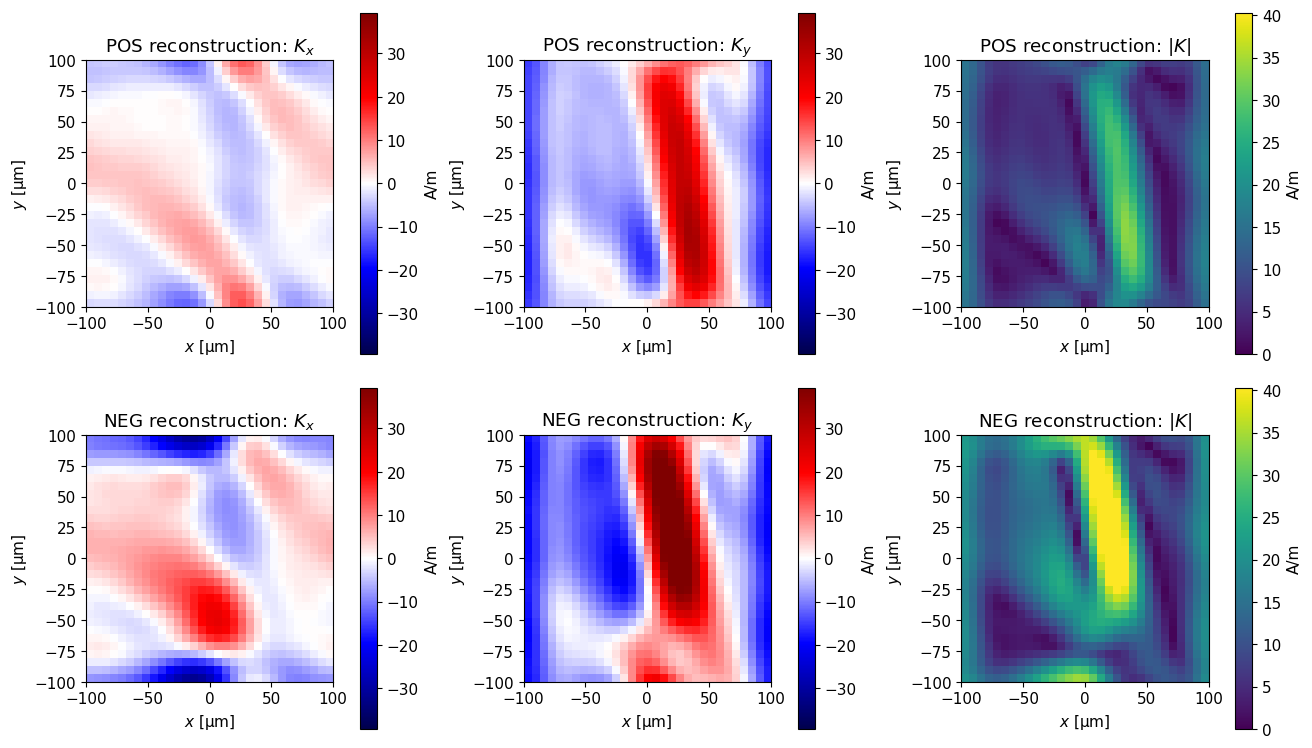

In [ ]:
# ============================================================
# Diagnostic: reconstruct POS and NEG separately using Bz only
# ============================================================

Kx_pos_A_per_m, Ky_pos_A_per_m, Kmag_pos_A_per_m, _, _ = reconstruct_current_from_Bz_only(
    Bz_nT=B_pos_nT[2],
    dx_m=dx_m,
    dy_m=dy_m,
    stand_off_um=STAND_OFF_UM,
    k_filter_fraction=K_FILTER_FRACTION,
    filter_power=FILTER_POWER,
)

Kx_neg_A_per_m, Ky_neg_A_per_m, Kmag_neg_A_per_m, _, _ = reconstruct_current_from_Bz_only(
    Bz_nT=B_neg_nT[2],
    dx_m=dx_m,
    dy_m=dy_m,
    stand_off_um=STAND_OFF_UM,
    k_filter_fraction=K_FILTER_FRACTION,
    filter_power=FILTER_POWER,
)

corr_Kx = np.corrcoef(Kx_pos_A_per_m.ravel(), (-Kx_neg_A_per_m).ravel())[0, 1]
corr_Ky = np.corrcoef(Ky_pos_A_per_m.ravel(), (-Ky_neg_A_per_m).ravel())[0, 1]
corr_Kmag = np.corrcoef(Kmag_pos_A_per_m.ravel(), Kmag_neg_A_per_m.ravel())[0, 1]

print("POS/NEG Bz-only current reconstruction consistency")
print("--------------------------------------------------")
print(f"corr(Kx_pos, -Kx_neg) = {corr_Kx:.3f}")
print(f"corr(Ky_pos, -Ky_neg) = {corr_Ky:.3f}")
print(f"corr(|K|_pos, |K|_neg) = {corr_Kmag:.3f}")

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5), constrained_layout=True)

plot_rows = [
    ("POS reconstruction", Kx_pos_A_per_m, Ky_pos_A_per_m, Kmag_pos_A_per_m),
    ("NEG reconstruction", -Kx_neg_A_per_m, -Ky_neg_A_per_m, Kmag_neg_A_per_m),
]

signed_lim = max(
    np.nanpercentile(np.abs(Kx_pos_A_per_m), 95),
    np.nanpercentile(np.abs(Ky_pos_A_per_m), 95),
    np.nanpercentile(np.abs(Kx_neg_A_per_m), 95),
    np.nanpercentile(np.abs(Ky_neg_A_per_m), 95),
)

mag_lim = max(
    np.nanpercentile(Kmag_pos_A_per_m, 95),
    np.nanpercentile(Kmag_neg_A_per_m, 95),
)

for row, (label, Kx_map, Ky_map, Kmag_map) in enumerate(plot_rows):
    maps = [
        (Kx_map, r"$K_x$", CMAP_B, -signed_lim, signed_lim),
        (Ky_map, r"$K_y$", CMAP_B, -signed_lim, signed_lim),
        (Kmag_map, r"$|K|$", CMAP_K, 0, mag_lim),
    ]

    for col, (data, title, cmap, vmin, vmax) in enumerate(maps):
        im = axes[row, col].imshow(
            data,
            extent=extent_um,
            origin="lower",
            aspect="equal",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        axes[row, col].set_title(f"{label}: {title}")
        axes[row, col].set_xlabel(r"$x$ [μm]")
        axes[row, col].set_ylabel(r"$y$ [μm]")
        plt.colorbar(im, ax=axes[row, col], label="A/m")

plt.show()

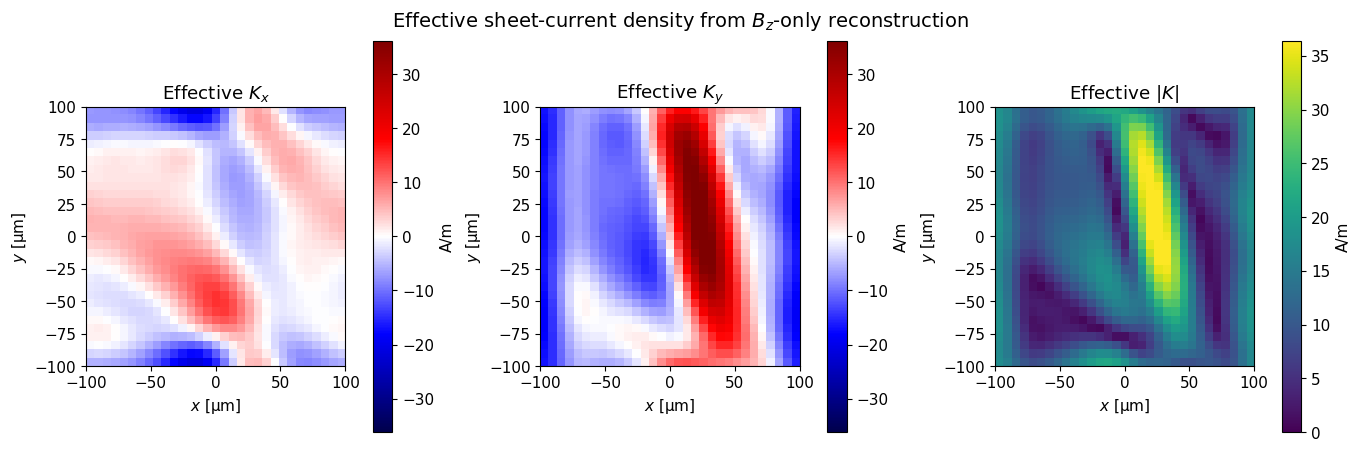

Effective current-density maps prepared:
  Kx_eff_A_per_m
  Ky_eff_A_per_m
  Kmag_eff_A_per_m


In [ ]:
# ============================================================
# Final effective current maps from POS/NEG Bz-only reconstruction
# ============================================================
# For a current-reversing signal:
#   K_pos should be approximately -K_neg.
#
# Therefore, the sign-corrected average current map is:
#   K_eff = 0.5 * (K_pos - K_neg)
#
# This suppresses non-current-reversing artefacts and keeps the part
# that changes sign with the applied current.
# ============================================================

Kx_eff_A_per_m = 0.5 * (Kx_pos_A_per_m - Kx_neg_A_per_m)
Ky_eff_A_per_m = 0.5 * (Ky_pos_A_per_m - Ky_neg_A_per_m)
Kmag_eff_A_per_m = np.sqrt(Kx_eff_A_per_m**2 + Ky_eff_A_per_m**2)

# Same maps with the NEG phase sign-corrected, useful for comparison
Kx_neg_flipped_A_per_m = -Kx_neg_A_per_m
Ky_neg_flipped_A_per_m = -Ky_neg_A_per_m

# ------------------------------------------------------------
# Report figure: effective current-density maps
# ------------------------------------------------------------

signed_lim = max(
    np.nanpercentile(np.abs(Kx_eff_A_per_m), 98),
    np.nanpercentile(np.abs(Ky_eff_A_per_m), 98),
)

mag_lim = np.nanpercentile(Kmag_eff_A_per_m, 98)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4), constrained_layout=True)

maps = [
    (Kx_eff_A_per_m, r"Effective $K_x$", CMAP_B, -signed_lim, signed_lim, "A/m"),
    (Ky_eff_A_per_m, r"Effective $K_y$", CMAP_B, -signed_lim, signed_lim, "A/m"),
    (Kmag_eff_A_per_m, r"Effective $|K|$", CMAP_K, 0, mag_lim, "A/m"),
]

for ax, (data, title, cmap, vmin, vmax, unit) in zip(axes, maps):
    im = ax.imshow(
        data,
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel(r"$x$ [μm]")
    ax.set_ylabel(r"$y$ [μm]")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(unit)

fig.suptitle(
    r"Effective sheet-current density from $B_z$-only reconstruction",
    fontsize=14,
)

plt.show()

print("Effective current-density maps prepared:")
print("  Kx_eff_A_per_m")
print("  Ky_eff_A_per_m")
print("  Kmag_eff_A_per_m")

In [ ]:
# ============================================================
# Project current density onto the wire direction
# ============================================================
# K_parallel is the current-density component along the wire.
# This is the component that should be integrated across the wire
# to estimate the total current.
# ============================================================

# Final manual integration choices
S_WINDOW_FINAL_UM = (-50, 50)      # along-wire averaging region
U_WINDOW_FINAL_UM = (-10, 70)      # transverse integration window


theta = np.deg2rad(WIRE_THETA_DEG)

# Unit vector along wire/current direction
u_parallel_vec = np.array([np.sin(theta), np.cos(theta)])

# Unit vector perpendicular to the wire
u_perp_vec = np.array([np.cos(theta), -np.sin(theta)])

X = x_grid_um
Y = y_grid_um

x_center_um = 0.5 * (np.nanmin(X) + np.nanmax(X))
y_center_um = 0.5 * (np.nanmin(Y) + np.nanmax(Y))

X0 = X - x_center_um
Y0 = Y - y_center_um

# Rotated coordinates
s_um = X0 * u_parallel_vec[0] + Y0 * u_parallel_vec[1]
u_um = X0 * u_perp_vec[0] + Y0 * u_perp_vec[1]

# Current-density component parallel to the wire
K_parallel_A_per_m = (
    Kx_eff_A_per_m * u_parallel_vec[0]
    + Ky_eff_A_per_m * u_parallel_vec[1]
)

print("Wire-aligned coordinates computed.")
print(f"WIRE_THETA_DEG = {WIRE_THETA_DEG:.2f} deg")
print(f"u_parallel = ({u_parallel_vec[0]:+.4f}, {u_parallel_vec[1]:+.4f})")
print(f"u_perp     = ({u_perp_vec[0]:+.4f}, {u_perp_vec[1]:+.4f})")
print(f"Final integration window: s = {S_WINDOW_FINAL_UM} µm, u = {U_WINDOW_FINAL_UM} µm")

Wire-aligned coordinates computed.
WIRE_THETA_DEG = -4.82 deg
u_parallel = (-0.0840, +0.9965)
u_perp     = (+0.9965, +0.0840)
Final integration window: s = (-50, 50) µm, u = (-10, 70) µm


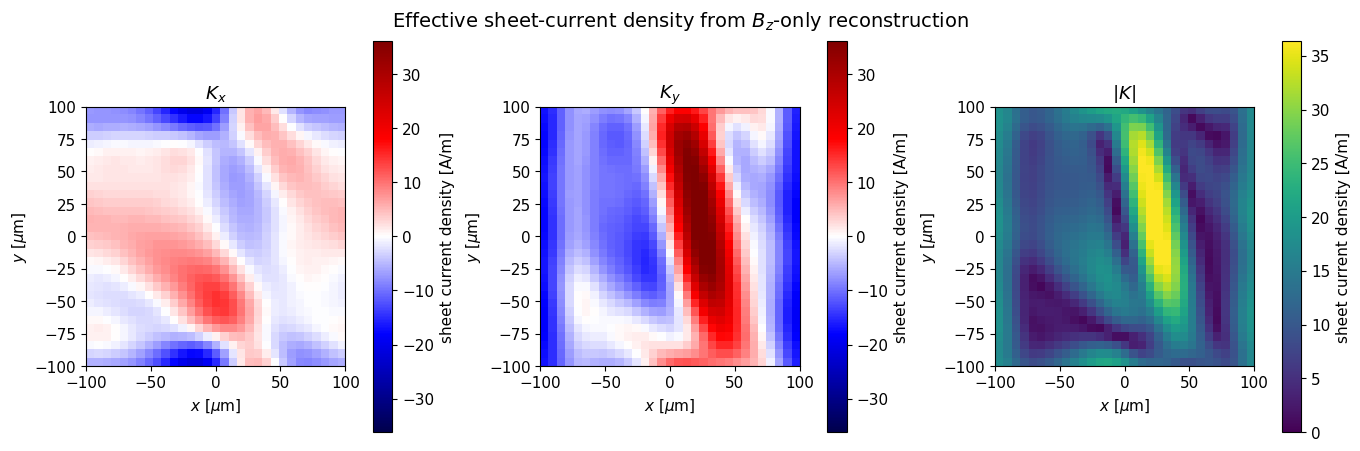

In [ ]:
# ============================================================
# Report Figure 1:
# Effective sheet-current density maps from Bz-only reconstruction
# ============================================================

Kmag_eff_A_per_m = np.sqrt(Kx_eff_A_per_m**2 + Ky_eff_A_per_m**2)

signed_lim = max(
    np.nanpercentile(np.abs(Kx_eff_A_per_m), 98),
    np.nanpercentile(np.abs(Ky_eff_A_per_m), 98),
)

mag_lim = np.nanpercentile(Kmag_eff_A_per_m, 98)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4), constrained_layout=True)

plot_items = [
    (Kx_eff_A_per_m, r"$K_x$", "seismic", -signed_lim, signed_lim),
    (Ky_eff_A_per_m, r"$K_y$", "seismic", -signed_lim, signed_lim),
    (Kmag_eff_A_per_m, r"$| K|$", "viridis", 0, mag_lim),
]

for ax, (data, title, cmap, vmin, vmax) in zip(axes, plot_items):
    im = ax.imshow(
        data,
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(title)
    ax.set_xlabel(r"$x$ [$\mu$m]")
    ax.set_ylabel(r"$y$ [$\mu$m]")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(r"sheet current density [A/m]")

fig.suptitle(
    r"Effective sheet-current density from $B_z$-only reconstruction",
    fontsize=14,
)

plt.show()

In [ ]:
# ============================================================
# Interpolate K_parallel and |K| along transverse profiles
# ============================================================

from scipy.interpolate import RegularGridInterpolator

N_S_PROFILES_FINAL = 61
N_U_SAMPLES_FINAL = 1001

s_values_final_um = np.linspace(
    S_WINDOW_FINAL_UM[0],
    S_WINDOW_FINAL_UM[1],
    N_S_PROFILES_FINAL,
)

u_values_um = np.linspace(-110, 110, N_U_SAMPLES_FINAL)

x_axis_um = np.asarray(x_grid_um[0, :], dtype=float)
y_axis_um = np.asarray(y_grid_um[:, 0], dtype=float)

def make_interpolator_from_map(map_2d):
    x_axis = x_axis_um.copy()
    y_axis = y_axis_um.copy()
    data = map_2d.copy()

    if x_axis[1] < x_axis[0]:
        x_axis = x_axis[::-1]
        data = data[:, ::-1]

    if y_axis[1] < y_axis[0]:
        y_axis = y_axis[::-1]
        data = data[::-1, :]

    return RegularGridInterpolator(
        (y_axis, x_axis),
        data,
        bounds_error=False,
        fill_value=np.nan,
    )

Kpar_interp = make_interpolator_from_map(K_parallel_A_per_m)
Kmag_interp = make_interpolator_from_map(Kmag_eff_A_per_m)

def sample_profile(interpolator, s0_um, u_array_um):
    x_line_um = (
        x_center_um
        + s0_um * u_parallel_vec[0]
        + u_array_um * u_perp_vec[0]
    )

    y_line_um = (
        y_center_um
        + s0_um * u_parallel_vec[1]
        + u_array_um * u_perp_vec[1]
    )

    points_yx = np.column_stack([y_line_um, x_line_um])
    return interpolator(points_yx)

Kpar_profiles_A_per_m = []
Kmag_profiles_A_per_m = []

for s0 in s_values_final_um:
    Kpar_profiles_A_per_m.append(sample_profile(Kpar_interp, s0, u_values_um))
    Kmag_profiles_A_per_m.append(sample_profile(Kmag_interp, s0, u_values_um))

Kpar_profiles_A_per_m = np.asarray(Kpar_profiles_A_per_m)
Kmag_profiles_A_per_m = np.asarray(Kmag_profiles_A_per_m)

Kpar_mean = np.nanmean(Kpar_profiles_A_per_m, axis=0)
Kpar_p16 = np.nanpercentile(Kpar_profiles_A_per_m, 16, axis=0)
Kpar_p84 = np.nanpercentile(Kpar_profiles_A_per_m, 84, axis=0)

Kmag_mean = np.nanmean(Kmag_profiles_A_per_m, axis=0)
Kmag_p16 = np.nanpercentile(Kmag_profiles_A_per_m, 16, axis=0)
Kmag_p84 = np.nanpercentile(Kmag_profiles_A_per_m, 84, axis=0)

u_mask_final = (
    (u_values_um >= U_WINDOW_FINAL_UM[0])
    & (u_values_um <= U_WINDOW_FINAL_UM[1])
)

print("Transverse profiles computed.")
print(f"s window = {S_WINDOW_FINAL_UM} µm")
print(f"u integration window = {U_WINDOW_FINAL_UM} µm")
print(f"Number of s profiles = {N_S_PROFILES_FINAL}")
print(f"Number of u samples = {N_U_SAMPLES_FINAL}")

Transverse profiles computed.
s window = (-50, 50) µm
u integration window = (-10, 70) µm
Number of s profiles = 61
Number of u samples = 1001


/tmp/ipykernel_63138/3075560827.py:70: RuntimeWarning: Mean of empty slice
  Kpar_mean = np.nanmean(Kpar_profiles_A_per_m, axis=0)
/home/vita/projects/NV_sensing/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/tmp/ipykernel_63138/3075560827.py:74: RuntimeWarning: Mean of empty slice
  Kmag_mean = np.nanmean(Kmag_profiles_A_per_m, axis=0)


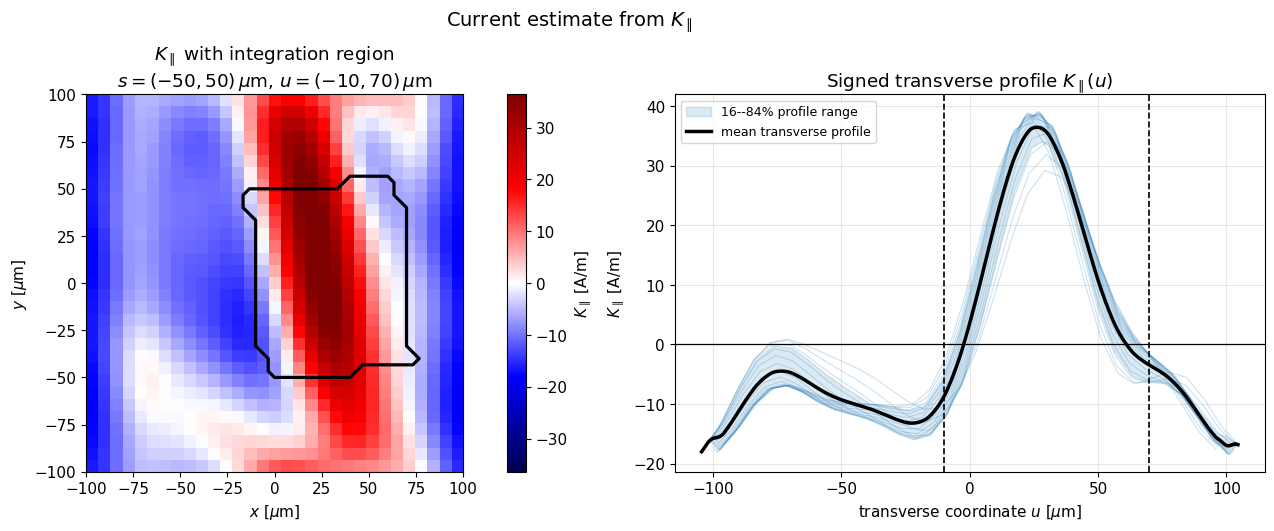

In [ ]:
# ============================================================
# Report Figure 2:
# K_parallel profile and signed current integration region
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), constrained_layout=True)

# ------------------------------------------------------------
# Left: K_parallel map with integration region
# ------------------------------------------------------------

lim = np.nanpercentile(np.abs(K_parallel_A_per_m), 98)

im = axes[0].imshow(
    K_parallel_A_per_m,
    extent=extent_um,
    origin="lower",
    aspect="equal",
    cmap="seismic",
    vmin=-lim,
    vmax=+lim,
)

region_mask = (
    (s_um >= S_WINDOW_FINAL_UM[0])
    & (s_um <= S_WINDOW_FINAL_UM[1])
    & (u_um >= U_WINDOW_FINAL_UM[0])
    & (u_um <= U_WINDOW_FINAL_UM[1])
)

axes[0].contour(
    x_grid_um,
    y_grid_um,
    region_mask.astype(float),
    levels=[0.5],
    colors="black",
    linewidths=2.3,
)

axes[0].set_title(
    rf"$K_\parallel$ with integration region"
    "\n"
    rf"$s={S_WINDOW_FINAL_UM}\,\mu$m, $u={U_WINDOW_FINAL_UM}\,\mu$m"
)
axes[0].set_xlabel(r"$x$ [$\mu$m]")
axes[0].set_ylabel(r"$y$ [$\mu$m]")

cbar = plt.colorbar(im, ax=axes[0])
cbar.set_label(r"$K_\parallel$ [A/m]")

# ------------------------------------------------------------
# Right: transverse K_parallel profile
# ------------------------------------------------------------

for idx, s0 in enumerate(s_values_final_um):
    if idx % 4 == 0:
        axes[1].plot(
            u_values_um,
            Kpar_profiles_A_per_m[idx],
            color="tab:blue",
            alpha=0.22,
            lw=0.8,
        )

axes[1].fill_between(
    u_values_um,
    Kpar_p16,
    Kpar_p84,
    color="tab:blue",
    alpha=0.16,
    label="16--84% profile range",
)

axes[1].plot(
    u_values_um,
    Kpar_mean,
    color="black",
    lw=2.5,
    label="mean transverse profile",
)


axes[1].axvline(U_WINDOW_FINAL_UM[0], color="black", ls="--", lw=1.2)
axes[1].axvline(U_WINDOW_FINAL_UM[1], color="black", ls="--", lw=1.2)
axes[1].axhline(0, color="black", lw=0.9)

axes[1].set_title(r"Signed transverse profile $K_\parallel(u)$")
axes[1].set_xlabel(r"transverse coordinate $u$ [$\mu$m]")
axes[1].set_ylabel(r"$K_\parallel$ [A/m]")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

fig.suptitle(
    r"Current estimate from $K_\parallel$",
    fontsize=14,
)

plt.show()

In [ ]:
# ============================================================
# Compute signed current from area under K_parallel
# ============================================================

def integrate_profiles_over_window(profiles_A_per_m, u_values_um, u_window_um):
    mask = (
        (u_values_um >= u_window_um[0])
        & (u_values_um <= u_window_um[1])
    )

    u_m = u_values_um[mask] * 1e-6

    I_profiles_mA = []

    for profile in profiles_A_per_m:
        y = profile[mask]
        valid = np.isfinite(y)

        if np.count_nonzero(valid) < 5:
            I_profiles_mA.append(np.nan)
            continue

        I_A = np.trapezoid(y[valid], u_m[valid])
        I_profiles_mA.append(1e3 * I_A)

    return np.asarray(I_profiles_mA, dtype=float)

I_signed_profiles_mA = integrate_profiles_over_window(
    profiles_A_per_m=Kpar_profiles_A_per_m,
    u_values_um=u_values_um,
    u_window_um=U_WINDOW_FINAL_UM,
)

I_signed_from_mean_mA = 1e3 * np.trapezoid(
    Kpar_mean[u_mask_final],
    u_values_um[u_mask_final] * 1e-6,
)

KNOWN_CURRENT_mA = I_POS_mA 

I_signed_median_mA = np.nanmedian(I_signed_profiles_mA)
I_signed_mean_mA = np.nanmean(I_signed_profiles_mA)
I_signed_std_mA = np.nanstd(I_signed_profiles_mA, ddof=1)
I_signed_p16_mA = np.nanpercentile(I_signed_profiles_mA, 16)
I_signed_p84_mA = np.nanpercentile(I_signed_profiles_mA, 84)

signed_current_df = pd.DataFrame([{
    "method": "signed integral of K_parallel",
    "s_window_um": str(S_WINDOW_FINAL_UM),
    "u_window_um": str(U_WINDOW_FINAL_UM),
    "I_from_mean_profile_mA": I_signed_from_mean_mA,
    "I_median_over_s_mA": I_signed_median_mA,
    "I_mean_over_s_mA": I_signed_mean_mA,
    "I_std_over_s_mA": I_signed_std_mA,
    "I_p16_mA": I_signed_p16_mA,
    "I_p84_mA": I_signed_p84_mA,
    "known_current_mA": KNOWN_CURRENT_mA,
    "fraction_of_known": abs(I_signed_median_mA) / KNOWN_CURRENT_mA,
}])

display(signed_current_df)

print("Signed current estimate")
print("-----------------------")
print(f"I from mean profile = {I_signed_from_mean_mA:+.3f} mA")
print(f"I median over s     = {I_signed_median_mA:+.3f} mA")
print(f"16--84% range       = {I_signed_p16_mA:+.3f} to {I_signed_p84_mA:+.3f} mA")
print(f"Known current       = {KNOWN_CURRENT_mA:.3f} mA")

,method,s_window_um,u_window_um,I_from_mean_profile_mA,I_median_over_s_mA,I_mean_over_s_mA,I_std_over_s_mA,I_p16_mA,I_p84_mA,known_current_mA,fraction_of_known
0,signed integral of K_parallel,"(-50, 50)","(-10, 70)",1.251996,1.289057,1.251996,0.110029,1.141989,1.34839,2.0,0.644528


Signed current estimate
-----------------------
I from mean profile = +1.252 mA
I median over s     = +1.289 mA
16--84% range       = +1.142 to +1.348 mA
Known current       = 2.000 mA


,method,s_window_um,u_window_um,I_from_mean_profile_mA,I_median_over_s_mA,I_mean_over_s_mA,I_std_over_s_mA,I_p16_mA,I_p84_mA,known_current_mA,fraction_of_known
0,integral of |K|,"(-50, 50)","(-5, 60)",1.466894,1.473832,1.466894,0.026985,1.45945,1.482885,2.0,0.736916


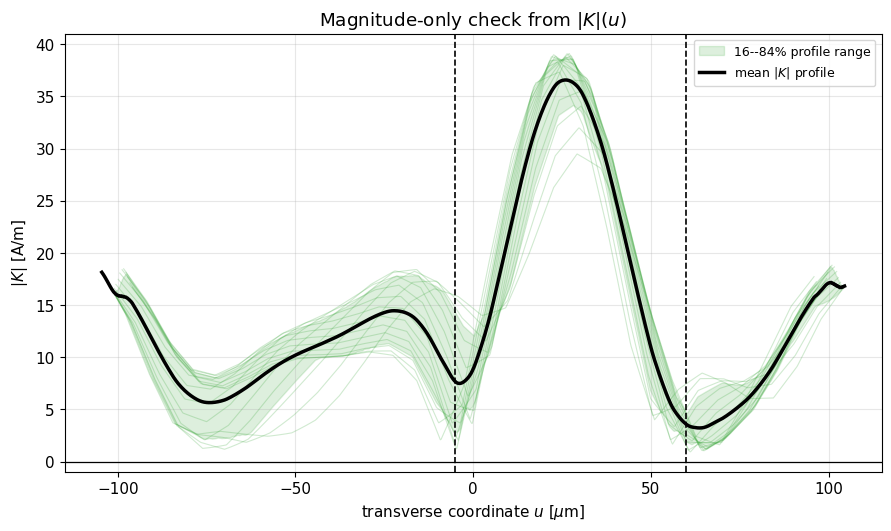

Magnitude-only current check
----------------------------
I from mean |K| profile = 1.467 mA
I median over s         = 1.474 mA
16--84% range           = 1.459 to 1.483 mA
Known current           = 2.000 mA


In [ ]:
# ============================================================
# Report Figure 3:
# Current-magnitude check from |K|
# ============================================================

I_Kmag_profiles_mA = integrate_profiles_over_window(
    profiles_A_per_m=Kmag_profiles_A_per_m,
    u_values_um=u_values_um,
    u_window_um=U_WINDOW_FINAL_UM,
)

I_Kmag_from_mean_mA = 1e3 * np.trapezoid(
    Kmag_mean[u_mask_final],
    u_values_um[u_mask_final] * 1e-6,
)

I_Kmag_median_mA = np.nanmedian(I_Kmag_profiles_mA)
I_Kmag_mean_mA = np.nanmean(I_Kmag_profiles_mA)
I_Kmag_std_mA = np.nanstd(I_Kmag_profiles_mA, ddof=1)
I_Kmag_p16_mA = np.nanpercentile(I_Kmag_profiles_mA, 16)
I_Kmag_p84_mA = np.nanpercentile(I_Kmag_profiles_mA, 84)

S_WINDOW_FINAL_UM_2 = (-50, 50)
U_WINDOW_FINAL_UM_2 = (-5, 60)

Kmag_current_df = pd.DataFrame([{
    "method": "integral of |K|",
    "s_window_um": str(S_WINDOW_FINAL_UM_2),
    "u_window_um": str(U_WINDOW_FINAL_UM_2),
    "I_from_mean_profile_mA": I_Kmag_from_mean_mA,
    "I_median_over_s_mA": I_Kmag_median_mA,
    "I_mean_over_s_mA": I_Kmag_mean_mA,
    "I_std_over_s_mA": I_Kmag_std_mA,
    "I_p16_mA": I_Kmag_p16_mA,
    "I_p84_mA": I_Kmag_p84_mA,
    "known_current_mA": KNOWN_CURRENT_mA,
    "fraction_of_known": I_Kmag_median_mA / KNOWN_CURRENT_mA,
}])

display(Kmag_current_df)

fig, ax = plt.subplots(figsize=(8.8, 5.2), constrained_layout=True)

for idx, s0 in enumerate(s_values_final_um):
    if idx % 4 == 0:
        ax.plot(
            u_values_um,
            Kmag_profiles_A_per_m[idx],
            color="tab:green",
            alpha=0.22,
            lw=0.8,
        )

ax.fill_between(
    u_values_um,
    Kmag_p16,
    Kmag_p84,
    color="tab:green",
    alpha=0.16,
    label="16--84% profile range",
)

ax.plot(
    u_values_um,
    Kmag_mean,
    color="black",
    lw=2.5,
    label=r"mean $|K|$ profile",
)


ax.axvline(U_WINDOW_FINAL_UM_2[0], color="black", ls="--", lw=1.2)
ax.axvline(U_WINDOW_FINAL_UM_2[1], color="black", ls="--", lw=1.2)
ax.axhline(0, color="black", lw=0.9)

ax.set_title(r"Magnitude-only check from $|K|(u)$")
ax.set_xlabel(r"transverse coordinate $u$ [$\mu$m]")
ax.set_ylabel(r"$|K|$ [A/m]")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

plt.show()

print("Magnitude-only current check")
print("----------------------------")
print(f"I from mean |K| profile = {I_Kmag_from_mean_mA:.3f} mA")
print(f"I median over s         = {I_Kmag_median_mA:.3f} mA")
print(f"16--84% range           = {I_Kmag_p16_mA:.3f} to {I_Kmag_p84_mA:.3f} mA")
print(f"Known current           = {KNOWN_CURRENT_mA:.3f} mA")